# TP6 : k plus proches voisins (KNN)

Importez les bibliothèques suivantes.

In [1]:
import numpy as np
import pandas as pd
import math
import seaborn as sns
import matplotlib.pyplot as plt

Les TPs précédents portaient sur le K-clustering, la PCA, la NMF, le MDS et l'Isomap. Le présent TP utilisant les résultats de ces derniers, voici une cellule important les classes `KMeans` (**[documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)**), `PCA` (**[documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)**) et `NMF` (**[documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.NMF.html)**) de la bibliothèque `sklearn`. Regardez bien les documentations. Le nom des attributs et méthodes n'est pas nécessairement le même que dans les classes que nous avons nous même définies.

In [2]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, NMF

Importez le jeu de données Fashion-MNIST complet via la fonction `fetch_openml` (**[documentation](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_openml.html)**). Nous travaillerons sur les 10 000 premières images et les 10 classes de vêtements correspondantes.

In [3]:
from sklearn.datasets import fetch_openml

X_full, y_full = fetch_openml('Fashion-MNIST', version=1, return_X_y=True, as_frame=False)
X = X_full[:10000]
y = y_full[:10000].astype(int)

print(f"Taille du dataset : {X.shape[0]} images de {X.shape[1]} pixels")
print(f"Classes présentes : {np.unique(y)}")

Taille du dataset : 10000 images de 784 pixels
Classes présentes : [0 1 2 3 4 5 6 7 8 9]


Les classes de vêtements sont étiquettées de la manière suivante :
- $0$ : T-shirt
- $1$ : Pantalon
- $2$ : Pull
- $3$ : Robe
- $4$ : Manteau
- $5$ : Sandale
- $6$ : Chemise
- $7$ : Basket
- $8$ : Sac
- $9$ : Bottine

---

## Introduction : de l'apprentissage non-supervisé à l'apprentissage supervisé

Jusqu'ici, tous les algorithmes que nous avons étudiés (K-means, PCA, NMF, MDS, Isomap) sont des méthodes d'apprentissage non-supervisé : ils cherchent une structure dans les données sans utiliser d'étiquettes. Nous avons par exemple regroupé les images en clusters et tenté de les interpréter a posteriori en comparant avec le vecteur `y` de vrais labels.

Nous entrons maintenant dans la partie d'apprentissage supervisé du cours. Cette fois, nous disposons dès le départ des étiquettes y pour une partie des données — le jeu d'entraînement `X_train`. L'objectif est d'apprendre, à partir de ces exemples étiquetés, une fonction capable de prédire l'étiquette de nouvelles données encore jamais vues — le jeu de test `X_test`.

Dans ce TP, nous allons implémenter l'algorithme des $k$ plus proches voisins (KNN). L'idée est intuitive : pour prédire la classe d'un nouvel exemple, on cherche les $k$ exemples d'entraînement qui lui ressemblent le plus au sens d'une distance, et on prédit la classe majoritaire parmi ces voisins.

Notez le lien fort avec ce que nous avons déjà fait : la notion de distance était déjà au cœur du K-clustering et du MDS.

## Construction de la classe MyKNN

Le but de ce TP est la création d'une classe permettant l'entraînement et la prédiction d'un modèle KNN. Nous allons la construire pas à pas grâce à la méthode du Monkey-Patching.

In [4]:
class MyKNN:
    def __init__(self, n_neighbors=5):
        self.k = n_neighbors
        
        # Attributs qui seront remplis lors de l'entraînement
        self.X_train = None
        self.y_train = None

print("Classe initialisée.")

Classe initialisée.


---

## Exercice 1 : distances entre un jeu d'entraînement et un jeu de test

Dans le TP5, nous avions construit une fonction `distances(data)` calculant la matrice de distances entre toutes les paires de points d'un même jeu de données. Ici, nous avons besoin de quelque chose de légèrement différent : calculer la distance entre chaque point de `X_test` et chaque point de `X_train`.

Formellement, si X_train est de taille $(n, p)$ et X_test de taille $(m, p)$, la matrice résultante $D$ doit être de taille $(m, n)$ avec :
$$D_{ij} = d(\text{X\_test}[i],\ \text{X\_train}[j])$$

Vous pouvez utiliser la même formule d'Al-Kashi que dans le TP5 :
$$d(x,y)^2 = \|x\|^2 + \|y\|^2 - 2\langle x,y \rangle$$

1. Construisez une fonction `cross_distances(X_train, X_test)` retournant cette matrice $D$ de taille $(m, n)$.

Note : comme dans le TP5, des erreurs d'approximation numérique peuvent produire de très petits nombres négatifs. Pensez à les ramener à zéro avant d'appliquer np.sqrt (**[documentation](https://numpy.org/doc/stable/reference/generated/numpy.sqrt.html)**).

In [33]:
# Écrivez votre code ici.
def cross_distances(X_train,X_test):
    xtr_norm=np.sum(X_train**2,axis=1)
    xt_norm=np.sum(X_test**2,axis=1)
    cross=np.dot(X_test,X_train.T)
    distances=xtr_norm[None,:]-2*cross+xt_norm[:,None]
    distances=np.maximum(distances,0)
    return np.sqrt(distances)
 
    

2. Vérifiez votre fonction sur un petit exemple. En prenant les 10 premières lignes de `X` à la fois comme `X_test` et comme  `X_train`, les distances d'un point à lui-même (la diagonale) doivent être nulles. Affichez cette diagonale.

In [34]:
X_ex=X[:10]
X_res=cross_distances(X_ex,X_ex)
print("Distances croisées calculées pour les 10 premières images (élements sur la diagonale):")
print(X_res.diagonal())


Distances croisées calculées pour les 10 premières images (élements sur la diagonale):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


---

## Exercice 2 : méthode fit

Contrairement aux algorithmes non-supervisés que nous avons vus, l'entraînement d'un KNN est extrêmement simple : il n'y a rien à calculer. Il s'agit uniquement de mémoriser le jeu d'entraînement X_train et les étiquettes associées y_train.

Ajoutez à la classe MyKNN une méthode `fit(self, X_train, y_train)` qui stocke X_train et y_train dans les attributs correspondants.

In [35]:
# Écrivez votre code ici.
def fit(self, X_train, y_train):
    self.X_train = X_train
    self.y_train = y_train
MyKNN.fit = fit

---

## Exercice 3 : méthode predict

C'est le cœur de l'algorithme. Pour chaque point de `X_test`, la méthode `predict` doit :

1. Calculer sa distance à tous les points de `X_train` en utilisant cross_distances.
2. Identifier les indices des $k$ points d'entraînement les plus proches.
3. Récupérer les étiquettes `y_train` de ces $k$ voisins.
4. Prédire la classe majoritaire parmi ces $k$ étiquettes.

Ajoutez à la classe `MyKNN` une méthode `predict(self, X_test)` qui retourne le vecteur des prédictions d'étiquettes.

Indication : np.argsort (**[documentation](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html)**) peut vous être utile pour trouver les indices des plus proches voisins. Pour le vote majoritaire, vous pouvez utiliser np.bincount (**[documentation](https://numpy.org/doc/stable/reference/generated/numpy.bincount.html)**) et np.argmax (**[documentation](https://numpy.org/doc/stable/reference/generated/numpy.argmax.html)**). De plus, vous pouvez utilisez une boucle for sur la longueur de `X_test`.

In [36]:
# Écrivez votre code ici.
def predict(self, X_test):
    all_distances = cross_distances(self.X_train, X_test)
    predictions = []
    
    for i in range(len(X_test)):
        distances = all_distances[i]
        
        indices = np.argsort(distances)
        k_indices = indices[:self.k]
        
        labels_voisins = self.y_train[k_indices].astype(int).flatten()
        
        votes = np.bincount(labels_voisins)
        pred = np.argmax(votes)
        predictions.append(pred)
        
    return np.array(predictions)

MyKNN.predict = predict

---

## Exercice 4 : méthode score

Ajoutez à la classe MyKNN une méthode `score(self, X_test, y_test)` qui retourne la précision (accuracy) du modèle sur le jeu de test : la proportion de prédictions correctes.

$$\text{accuracy} = \frac{\text{nombre de prédictions correctes}}{\text{nombre total de prédictions}}$$

In [37]:
# Écrivez votre code ici.
def score(self, X_test, y_test):
    predictions=self.predict(X_test)
    return np.mean(predictions==y_test)
MyKNN.score = score

---

## Exercice 5 : premier test et matrice de confusion

Nous allons maintenant tester notre implémentation. Divisez le dataset en un jeu d'entraînement (80% des données) et un jeu de test (20% des données) en utilisant np.random.permutation (**[documentation](https://numpy.org/doc/stable/reference/random/generated/numpy.random.permutation.html)**) pour mélanger aléatoirement les indices.

1. Entraînez un modèle `MyKNN` avec $k=5$ sur `X_train` et calculez sa précision sur `X_test`.

Note : le calcul peut prendre quelques dizaines de secondes, car il faut calculer les distances entre les 2000 points de test et les 8000 points d'entraînement dans un espace de dimension $784$.

In [38]:
indices=np.random.permutation(len(X))
X_train=X[indices[:8000]]
y_train=y[indices[:8000]]
X_test=X[indices[8000:]]
y_test=y[indices[8000:]]
knn=MyKNN(n_neighbors=5)
knn.fit(X_train,y_train)
accuracy=knn.score(X_test,y_test)
print(f"Précision du KNN sur le jeu de test : {accuracy:.4f}")


Précision du KNN sur le jeu de test : 0.8220


2.  La matrice de confusion est un tableau carré de taille $C \times C$ où $C$ est le nombre de classes. La case $(i,j)$ contient le nombre d'exemples dont le vrai label est $i$ et dont le label prédit est $j$. Calculez et affichez la matrice de confusion à l'aide de pd.crosstab (**[documentation](https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html)**) et sns.heatmap (**[documentation](https://seaborn.pydata.org/generated/seaborn.heatmap.html)**). Quelle interprétation peut-on donner à la diagonale ? Au reste de la matrice ? Quelles classes sont le plus souvent confondues entre elles ? Cela vous semble-t-il cohérent ?

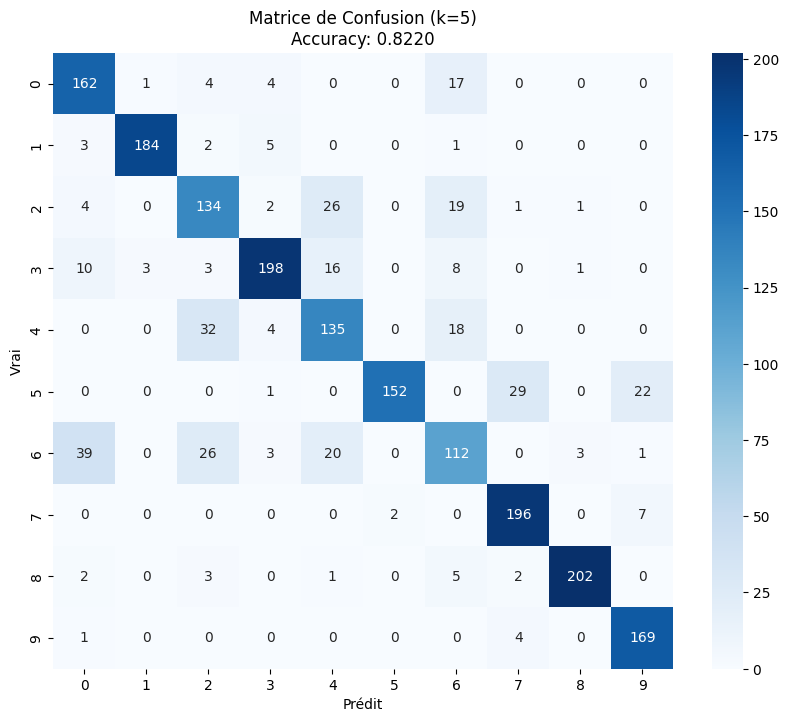

In [39]:
# Écrivez votre code ici.
conf_matrix=pd.crosstab(y_test, knn.predict(X_test), rownames=['Vrai'], colnames=['Prédit'])
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title(f"Matrice de Confusion (k=5)\nAccuracy: {accuracy:.4f}")
plt.show()

La Diagonale : Elle regroupe les prédictions correctes. Plus les chiffres y sont élevés, plus le modèle KNN est performant pour ces classes. Une diagonale sombre sur la heatmap est signe d'une bonne précision
.Hors-Diagonale : Ce sont les erreurs. Chaque valeur dans la case $(i, j)$ indique combien de fois la classe i a été prise pour la classe j.
Confusions majeures : On les repère via les chiffres les plus élevés en dehors de la diagonale. Par exemple, si vous voyez un pic pour les classes 4 et 9, c'est que le modèle les confond souvent.
Cohérence : Pour un KNN, ces erreurs sont cohérentes si les classes confondues se ressemblent physiquement (ex: formes proches). Comme KNN se base sur la distance, des données aux caractéristiques similaires finiront naturellement proches l'une de l'autre, provoquant ces erreurs.

---

## Exercice bonus 1 : impact de la taille du jeu d'entraînement

Le KNN mémorise les données d'entraînement sans rien calculer dans la méthode fit. On pourrait donc penser que disposer de plus ou moins d'exemples ne change rien à l'algorithme en lui-même. Pourtant, la taille du jeu d'entraînement est un facteur déterminant pour la qualité des prédictions.

1. Construisez une fonction `test_train_size(n_train)` qui, pour un nombre d'exemples d'entraînement `n_train donné`, entraîne un `MyKNN` avec $k=5$ sur les `n_train` premiers exemples de `X_trainè  et retourne la précision sur `X_test`.

Appelez cette fonction pour les valeurs suivantes : $50, 100, 200, 500, 1000, 2000, 4000, 8000$. Tracez la courbe d'accuracy en fonction de `n_train`.

Note : veillez à utiliser le même jeu de test `X_test` à chaque fois, afin que les comparaisons soient équitables.

Text(0, 0.5, 'Précision sur le jeu de test')

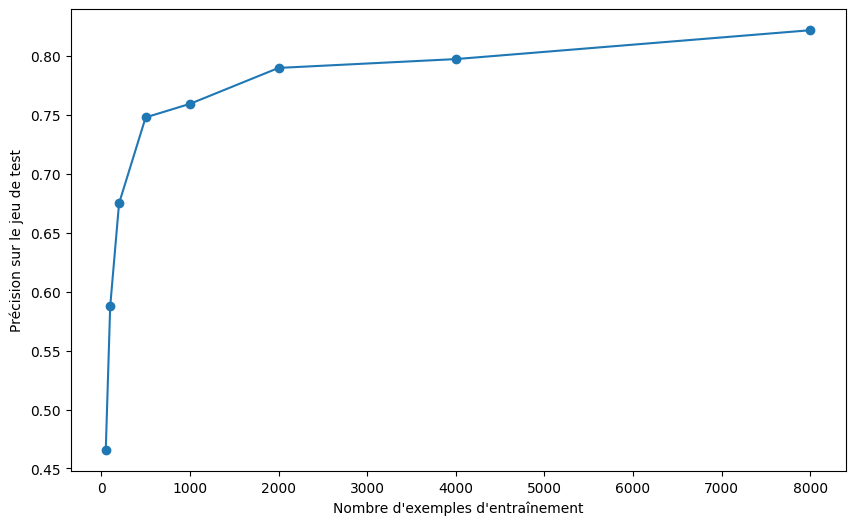

In [40]:
# Écrivez votre code ici.
def test_train(n_train):
    myknn=MyKNN(5)
    myknn.fit(X_train[:n_train],y_train[:n_train])
    return myknn.score(X_test,y_test)

sizes=[50,100,200,500,1000,2000,4000,8000]
accuracies = [test_train(n) for n in sizes]
plt.figure(figsize=(10, 6))
plt.plot(sizes, accuracies, marker='o')
plt.xlabel('Nombre d\'exemples d\'entraînement')
plt.ylabel('Précision sur le jeu de test')

2. Décrivez la forme de la courbe. Y a-t-il un palier ? Que se passe-t-il pour de très petits jeux d'entraînement ? Cette courbe vous semble-t-elle converger ?

La courbe suit une allure croissante et concave : l'accuracy grimpe vite au début puis finit par stagner. Pour de très petits jeux d'entraînement, les résultats sont faibles et instables car le modèle manque de points de comparaison pour faire un choix fiable. On observe ensuite un palier (plateau) à partir d'un certain nombre d'exemples, ce qui montre que le modèle finit par converger. Cela signifie qu'une fois que l'espace des données est assez dense, ajouter de nouveaux exemples n'apporte plus d'informations majeures et la précision atteint son plafond naturel

---

## Exercice bonus 2 : visualisation des erreurs

Pour mieux comprendre les limites du modèle, nous allons examiner les images mal classifiées par le KNN (k=5, 80% train). Pour chacune, nous allons également afficher ses 5 plus proches voisins dans le jeu d'entraînement, afin de comprendre pourquoi le modèle s'est trompé. Nous utiliserons la fonction `display_image`.

In [41]:
def display_image(source):
    if len(source) == 784:
        images = [source]
    elif len(source[0]) == 784:
        images = source
    else:
        print("error")
    
    l = len(images)
    c = math.ceil(l / 3)
    fig, axes = plt.subplots(c, 3, figsize=(12, 5))

    for i, ax in enumerate(axes.flat):
        if i < l:
            img = images[i].reshape(28, 28)
            ax.imshow(img, cmap='gray')
            ax.set_title(f"Image {i + 1}")
        ax.axis('off')

Construisez une fonction `display_errors(knn, X_test, y_test, n_errors)` qui affiche les `n_errors premières` erreurs du modèle. Pour chaque erreur, affichez : 
- le vrai label de l'image, le label prédit et les labels des $k$ plus proches voisins,
- l'image mal classifiée et les images de ses $k$ plus proches voisins.

Erreur 1: Vrai=4, Prédit=2


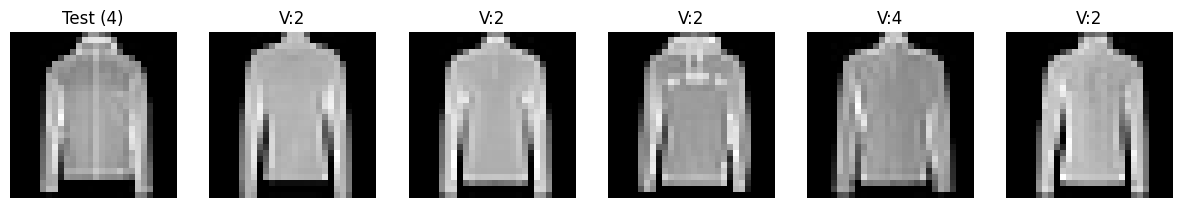

Erreur 2: Vrai=4, Prédit=2


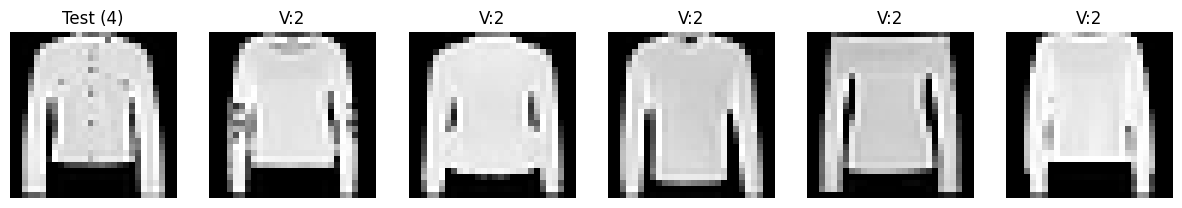

Erreur 3: Vrai=6, Prédit=3


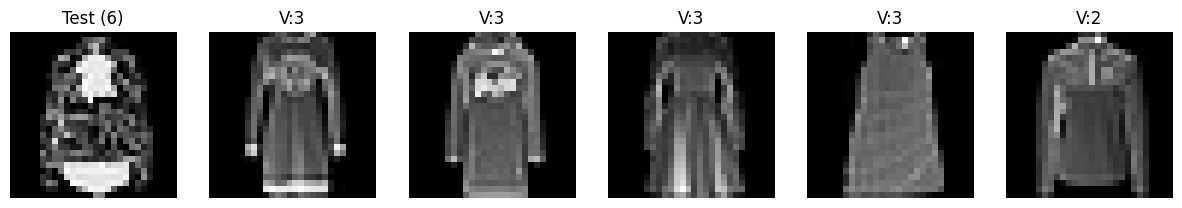

Erreur 4: Vrai=0, Prédit=3


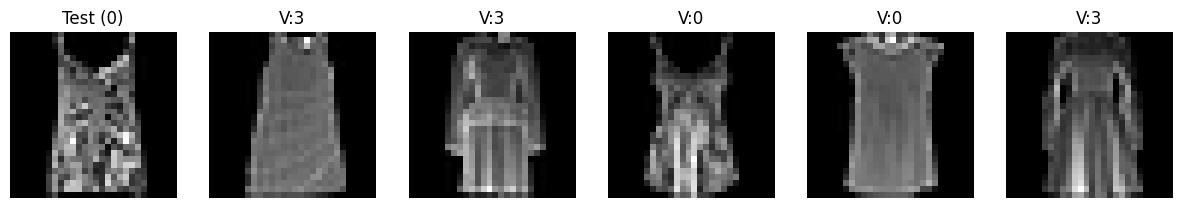

Erreur 5: Vrai=2, Prédit=6


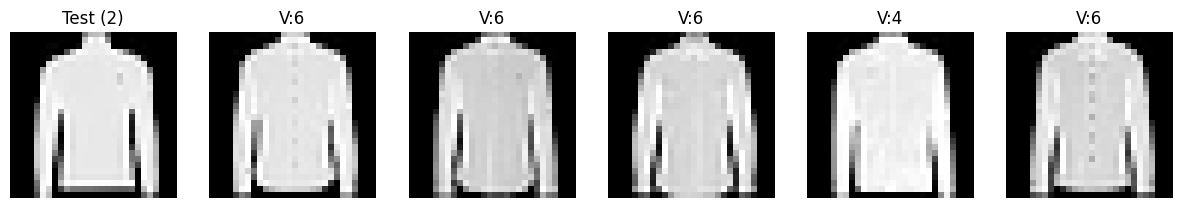

In [ ]:

def display_errors(knn, X_test, y_test, n_errors=5):
    y_pred = knn.predict(X_test)
    indices_erreurs = np.where(y_pred != y_test)[0]
    k = knn.k 
    
    for i in range(min(n_errors, len(indices_erreurs))):
        idx = indices_erreurs[i]
        image_test = X_test[idx]
        
        
        dists = cross_distances(X_train, image_test.reshape(1, -1))
        voisins_idx = np.argsort(dists, axis=1).flatten()[:k]
        print(f"Erreur {i+1}: Vrai={y_test[idx]}, Prédit={y_pred[idx]}")
        plt.figure(figsize=(15, 3))
        plt.subplot(1, k + 1, 1)
        plt.imshow(image_test.reshape(28, 28), cmap='gray')
        plt.title(f"Test ({y_test[idx]})")
        plt.axis('off')
        
        
        for j in range(k):
            v_idx = voisins_idx[j] 
            plt.subplot(1, k + 1, j + 2)
            plt.imshow(X_train[v_idx].reshape(28, 28), cmap='gray')
            plt.title(f"V:{y_train[v_idx]}")
            plt.axis('off')
        plt.show()

display_errors(knn, X_test, y_test, n_errors=5)

Les erreurs vous semblent-elles compréhensibles ? Y a-t-il des cas ambigus même pour un œil humain ? Que nous dit cela sur les limites de la distance euclidienne comme mesure de similarité entre images ?

Les erreurs du modèle sont compréhensibles car elles touchent des catégories aux silhouettes similaires, comme les T-shirts et les chemises. On observe des cas ambigus où même un humain hésite à cause de la faible résolution (28x28) qui masque les détails (cols, boutons). Cela illustre les limites de la distance euclidienne : elle compare les pixels position par position sans comprendre la structure. Un simple décalage d'un pixel ou une variation de luminosité suffit à fausser la mesure, prouvant que cette métrique capte une proximité numérique brute plutôt qu'une réelle ressemblance visuelle.